In [1]:
# ====================================================
# Libraries
# ====================================================

import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp, trapezoid, cumulative_trapezoid
from scipy.interpolate import RegularGridInterpolator
from multiprocessing import Pool
import os
import time
import emcee
from getdist import MCSamples, plots
import matplotlib.pyplot as plt

In [2]:
# =========================
# Loading CC data
# =========================

cc_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/CC/CC_Hz_data.txt"
df_cc = pd.read_csv(cc_dat_path, sep=r"\s+")
z_cc   = df_cc["z_cc"].to_numpy(float)
H_obs  = df_cc["H_cc"].to_numpy(float)
H_err   = df_cc["H_cc_err"].to_numpy(float)


# =========================
# Loading SNe Ia data (Pantheon+SH0ES)
# =========================

sne_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/SNe/Pantheon+SH0ES.dat"
sne_cov_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/SNe/Pantheon+SH0ES_STAT+SYS.cov"
df_sne = pd.read_csv(sne_dat_path, sep=r"\s+", comment="#", engine="python")
raw_cov = np.loadtxt(sne_cov_path, skiprows=1)
Cov_sne_full = raw_cov.reshape((1701, 1701))
mask = df_sne["zCMB"].values > 0.01
df_cut = df_sne[mask].reset_index(drop=True)
Cov_sne = Cov_sne_full[mask, :][:, mask]
z_sne = df_cut["zCMB"].values
mB_obs = df_cut["m_b_corr"].values
Cinv_sne = np.linalg.inv(Cov_sne)


# ====================================================
# Loading BAO data (DESI_DR2)
# ====================================================

bao_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/BAO/desi_gaussian_bao_ALL_GCcomb_mean.txt"
bao_cov_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/BAO/desi_gaussian_bao_ALL_GCcomb_cov.txt"
df_bao = pd.read_csv(bao_dat_path, sep=r"\s+", comment="#", names=["z", "value", "quantity"])
z_bao = df_bao["z"].values
d_obs = df_bao["value"].values
q_bao = df_bao["quantity"].str.lower().values
cov_bao  = np.loadtxt(bao_cov_path)
Cinv_bao = np.linalg.inv(cov_bao)

In [3]:
# ====================================================
# Fiducial / Priors
# ====================================================
 
# Hard bounds
H0_min,  H0_max  = 50.0,  90.0
Om0_min, Om0_max = 0.1,   0.6
Ob_min,  Ob_max  = 0.01,  0.1
MB_min,  MB_max  = -20.0, -18.0
lbd_min, lbd_max = 1.54,  10.0

# Physical constants
c_kms = 299792.458         # speed of light [km/s]

# Cosmological/astrophysical parameters
Neff = 3.046

# HS model index (fixed)
n = 1

# Scalaron mass scale
delta_s = 1e-7


# ====================================================
# Redshift / scale-factor / number of e-folds grids
# ====================================================

ai,    af    = 0.2,        1.0
zi,    zf    = 0.0,        4.0
ln_ai, ln_af = np.log(ai), np.log(af)

N_grid = 300
z_grid = np.linspace(zi, zf, N_grid)
dz     = np.diff(z_grid)  

In [4]:
# ====================================================
# Custom exception for ODE failure
# ====================================================

class ODEFailure(Exception):
    pass


# ====================================================
# ODE system for yH(t=lna) in ST f(R) gravity
# ====================================================

def yH_ST_ode(lna, y, H0, Om0, lbd):
    
    yH, YH = y
    a = np.exp(lna)
    
    ms  = H0**2 * Om0
    Rs  = 6.0 * H0**2 * (1.0 - Om0) / lbd
    M2  = Rs / delta_s
    
    R = 3.0 * ms * (YH + 4*yH + a**(-3))
    
    ratio = R / Rs
    ratio2 = ratio**2
    term_base = 1.0 + ratio2
    
    f_R = R + lbd * Rs * (term_base**(-n) - 1) + R**2 / (6 * M2)
    fR = 1.0 - 2.0 * n * lbd * ratio * term_base**(-n-1) + R / (3 * M2)
    fRR = -(2.0 * n * lbd / Rs) * term_base**(-n-1) * ( 1.0 - 2*(n + 1) * ratio2 * term_base**(-1) ) + 1.0 / (3 * M2)
    
    if fRR == 0.0 or not np.isfinite(fRR):
        raise ODEFailure(f"fRR singular at lna={lna:.4f}")
    
    yaux1 = yH + a**(-3)
    yaux2 = a**(-3)
    yaux3 = ((1 - fR) * yaux2) + ((R - f_R) / (3 * ms))
    
    J1 = 4.0 + (1.0 / yaux1) * ((1.0 - fR) / (6.0 * ms * fRR))
    J2 = (1.0 / yaux1) * ((2.0 - fR) / (3.0 * ms * fRR))
    J3 = -(3.0 * yaux2) - (yaux3 / yaux1) * (1.0 / (6.0 * ms * fRR))
    
    dYH = -J1 * YH - J2 * yH - J3
    return [YH, dYH]


# ====================================================
# ODE integration → H(lna)
# ====================================================

def H_ST_lna(lna_eval, H0, Om0, lbd):
    ms  = H0**2 * Om0
    yH0 = (1.0 - Om0) / Om0
    YH0 = 0.0
    y0  = [yH0, YH0]
    try:
        sol = solve_ivp(
            yH_ST_ode,
            (ln_ai, ln_af),
            y0,
            t_eval=lna_eval,
            method="LSODA",
            rtol=1e-6,
            atol=1e-8,
            args=(H0, Om0, lbd),
            dense_output=False
        )
    except Exception:
        return None
    if sol.status < 0 or np.any(~np.isfinite(sol.y)):
        return None
    a_eval = np.exp(lna_eval)
    yH_sol = sol.y[0]
    H_sol  = np.sqrt(ms * (yH_sol + a_eval**(-3)))
    return H_sol


# ====================================================
# H(z) via lna = - ln(1+z) conversion
# ====================================================

def H_ST_z(z_eval, H0, Om0, lbd):
    z_eval    = np.atleast_1d(np.asarray(z_eval, dtype=float))
    lna_eval  = - np.log(1.0 + z_eval)
    in_domain = (lna_eval >= ln_ai) & (lna_eval <= ln_af)
    if not np.any(in_domain):
        return None
    valid_idx   = np.where(in_domain)[0]
    lna_valid   = lna_eval[valid_idx]
    sort_idx    = np.argsort(lna_valid)
    lna_sorted  = lna_valid[sort_idx]
    unique_mask = np.concatenate(([True], np.diff(lna_sorted) > 1e-12))
    lna_unique  = lna_sorted[unique_mask]
    H_unique    = H_ST_lna(lna_unique, H0, Om0, lbd)
    if H_unique is None:
        return None
    if not np.all(unique_mask):
        H_at_sorted = np.interp(lna_sorted, lna_unique, H_unique)
    else:
        H_at_sorted = H_unique
    H_valid           = np.empty(len(lna_valid))
    H_valid[sort_idx] = H_at_sorted
    H_z               = np.full(len(z_eval), np.nan)
    H_z[valid_idx]    = H_valid
    return H_z

In [5]:
# # ====================================================
# # Worker function (module level — required for pickle)
# # ====================================================

# def _grid_worker_ST(args):
#     """
#     Computes H(z) for a single (H0, Om0, lbd) grid point.
#     The grid is always built in LINEAR lbd space.
#     Returns (i, j, k, H_values) or (i, j, k, None) on failure.
#     """
    
#     i, j, k, H0, Om0, lbd, z_pts = args
#     Hvals = H_ST_z(z_pts, H0, Om0, lbd)
#     if Hvals is not None and np.all(np.isfinite(Hvals)):
#         return (i, j, k, Hvals)
#     else:
#         return (i, j, k, None)


# # ====================================================
# # Parallel grid builder
# # ====================================================

# def build_H_grid_parallel_ST(H0_pts, Om0_pts, lbd_pts, z_pts,
#                               n_cores=None, verbose=True):
#     nH    = len(H0_pts)
#     nOm   = len(Om0_pts)
#     nlbd  = len(lbd_pts)
#     nz    = len(z_pts)
#     total = nH * nOm * nlbd
#     n_cores = n_cores or os.cpu_count()
#     tasks = [
#         (i, j, k, H0, Om0, lbd, z_pts)
#         for i, H0  in enumerate(H0_pts)
#         for j, Om0 in enumerate(Om0_pts)
#         for k, lbd in enumerate(lbd_pts)
#     ]
#     H_array   = np.full((nH, nOm, nlbd, nz), np.nan)
#     nan_count = 0
#     if verbose:
#         print(f"  ST model index    : n = {n}")
#         print(f"  Total grid points : {total} ({nH}×{nOm}×{nlbd})")
#         print(f"  Workers           : {n_cores}")
#         print(f"  {'PCT':>5}  {'Done':>8}  {'Elapsed':>9}  {'ETA':>9}  {'Rate':>12}")
#         print("  " + "-"*55)
#     t0       = time.time()
#     count    = 0
#     last_pct = -1
#     chunksize = max(1, total // (n_cores * 20))
#     with Pool(processes=n_cores) as pool:
#         for result in pool.imap_unordered(_grid_worker_ST, tasks,
#                                           chunksize=chunksize):
#             i, j, k, Hvals = result
#             if Hvals is not None:
#                 H_array[i, j, k, :] = Hvals
#             else:
#                 nan_count += 1
#             count   += 1
#             elapsed  = time.time() - t0
#             pct      = int(count / total * 100)
#             if verbose and (pct >= last_pct + 10 or count == total):
#                 eta  = (elapsed / count) * (total - count) if count < total else 0.0
#                 rate = count / elapsed if elapsed > 0 else 0.0
#                 print(f"  {pct:>4}%  {count:>8}/{total}  "
#                       f"{elapsed:>7.1f}s  "
#                       f"ETA {eta:>6.1f}s  "
#                       f"{rate:>8.1f} pts/s")
#                 last_pct = pct
#     nan_frac = nan_count / total
#     if nan_frac > 0:
#         print(f"\n  ⚠  {100*nan_frac:.1f}% NaN in grid — "
#               f"check prior bounds or ODE stability.")
#     else:
#         print(f"\n  ✓  Grid complete with no NaN points.")
#     total_time = time.time() - t0
#     print(f"  Total time: {total_time:.1f}s ({total_time/60:.2f} min)")
#     return H_array


# # ====================================================
# # Interpolation error validation
# # ====================================================

# def validate_interpolation_error_ST(H_interp_4D, H0_pts, Om0_pts, lbd_pts, z_pts,
#                                     n_test=300, tol_percent=0.5):
#     """
#     Validates the interpolator against direct ODE solutions at
#     n_test random interior points (sampled in LINEAR lbd space).
#     """
    
#     rng_v  = np.random.default_rng(0)
#     errors = []
#     for _ in range(n_test):
#         H0_t    = rng_v.uniform(H0_pts[1],   H0_pts[-2])
#         Om0_t   = rng_v.uniform(Om0_pts[1],  Om0_pts[-2])
#         lbd_t   = rng_v.uniform(lbd_pts[1],  lbd_pts[-2])
#         H_true  = H_ST_z(z_pts, H0_t, Om0_t, lbd_t)
#         if H_true is None or not np.all(np.isfinite(H_true)):
#             continue
#         pts      = np.column_stack([np.full(len(z_pts), H0_t),
#                                     np.full(len(z_pts), Om0_t),
#                                     np.full(len(z_pts), lbd_t),
#                                     z_pts])
#         H_interp = H_interp_4D(pts)
#         rel_err  = np.abs((H_true - H_interp) / H_true) * 100.0
#         errors.append(np.max(rel_err))
#     errors = np.array(errors)
#     print(f"\n  Interpolation validation ({n_test} random interior points):")
#     print(f"  Max error    : {errors.max():.4f}%")
#     print(f"  Median error : {np.median(errors):.4f}%")
#     print(f"  95th pct     : {np.percentile(errors, 95):.4f}%")
#     if errors.max() < tol_percent:
#         print(f"  ✓  Interpolator approved (max error < {tol_percent}%). "
#               f"Ready for MCMC.")
#     else:
#         print(f"  ✗  Max error exceeds {tol_percent}%! "
#               f"Increase grid resolution (n_H0, n_Om0, n_lbd).")
#     return errors


# # ====================================================
# # 4D interpolation grid parameters
# # ====================================================

# n_H0  = 30
# n_Om0 = 30
# n_lbd = 30

# H0_grid_pts  = np.linspace(H0_min,  H0_max,  n_H0)
# Om0_grid_pts = np.linspace(Om0_min, Om0_max, n_Om0)
# lbd_grid_pts = np.linspace(lbd_min, lbd_max, n_lbd)


# # ====================================================
# # Build grid (parallel)
# # ====================================================

# print(f"\n=== Building 4D interpolation grid (parallel) | ST n={n} ===")
# H_array = build_H_grid_parallel_ST(
#     H0_grid_pts, Om0_grid_pts, lbd_grid_pts, z_grid,
#     n_cores=os.cpu_count()
# )


# # ====================================================
# # Save grid for reuse
# # ====================================================

# np.save(f"H_array_ST_n{n}_{n_lbd}_grid.npy", H_array)


# # ====================================================
# # Build interpolator
# # ====================================================

# H_interp_4D = RegularGridInterpolator(
#     (H0_grid_pts, Om0_grid_pts, lbd_grid_pts, z_grid),
#     H_array,
#     method="linear",
#     bounds_error=False,
#     fill_value=np.nan
# )


# # ====================================================
# # Validate interpolator
# # ====================================================

# print(f"\n=== Validating interpolator | ST n={n} ===")
# errors = validate_interpolation_error_ST(
#     H_interp_4D, H0_grid_pts, Om0_grid_pts, lbd_grid_pts, z_grid
# )


# =====================================================
# Load and validation of the grid
# =====================================================

# 4D interpolation grid parameters
n_H0  = 30
n_Om0 = 30
n_lbd = 30

H0_grid_pts  = np.linspace(H0_min,  H0_max,  n_H0)
Om0_grid_pts = np.linspace(Om0_min, Om0_max, n_Om0)
lbd_grid_pts = np.linspace(lbd_min, lbd_max, n_lbd)

# Load grid from file
H_array_path = "/home/brunowesley/projetos/MCMC-cosmo/Codes/MG-based/Starobinsky/CC/H_array_ST_n1_30_grid.npy"
H_array = np.load(H_array_path)

# Build interpolator
H_interp_4D = RegularGridInterpolator(
    (H0_grid_pts, Om0_grid_pts, lbd_grid_pts, z_grid),
    H_array,
    method="linear",
    bounds_error=False,
    fill_value=np.nan
)

In [6]:
# ====================================================
# H(z) via interpolator
# ====================================================

def H_ST_interp(z_eval, H0, Om0, lbd):
    """Query interpolator with physical (linear) lbd."""
    
    pts = np.column_stack([
        np.full(len(z_eval), H0),
        np.full(len(z_eval), Om0),
        np.full(len(z_eval), lbd),
        z_eval
    ])
    return H_interp_4D(pts)


# ====================================================
# mB(z) via interpolator
# ====================================================

def dL_ST_interp(z, H0, Om0, lbd):
    H_interp  = H_ST_interp(z_grid, H0, Om0, lbd)
    prefactor = c_kms * (1.0 + z)
    integrand = 1.0 / H_interp
    integral  = cumulative_trapezoid(integrand, z_grid, initial=0.0)
    I_z       = np.interp(z, z_grid, integral)
    return prefactor * I_z

def mB_ST_interp(z, H0, Om0, MB, lbd):
    dL = dL_ST_interp(z, H0, Om0, lbd)
    mu = 5.0 * np.log10(dL) + 25.0
    return mu + MB


# ====================================================
# d_bao(z) via interpolator
# ====================================================

def comoving_dist_interp(z, H0, Om0, lbd):
    H_interp     = H_ST_interp(z_grid, H0, Om0, lbd)
    integrand    = 1.0 / H_interp
    integral     = np.empty_like(z_grid)
    integral[0]  = 0.0
    integral[1:] = np.cumsum(0.5 * (integrand[1:] + integrand[:-1]) * dz)
    I_z          = np.interp(z, z_grid, integral)
    return c_kms * I_z

def d_bao_ST_interp(z_arr, q_arr, H0, Om0, Ob, lbd):
    h2   = (H0 / 100.0)**2
    Obh2 = Ob * h2
    Omh2 = Om0 * h2
    rd   = 147.05 * ((Obh2 / 0.02236)**-0.13) \
                  * ((Omh2 / 0.1432)**-0.23)  \
                  * ((Neff  / 3.04)**-0.1)
    dC  = comoving_dist_interp(z_arr, H0, Om0, lbd)
    H_z = H_ST_interp(z_arr, H0, Om0, lbd)
    dm  = dC / rd
    dh  = (c_kms / H_z) / rd
    dv  = (z_arr * dm**2 * dh)**(1.0 / 3.0)

    d_bao          = np.empty_like(z_arr)
    mask_dv        = np.array(["dv" in q for q in q_arr])
    mask_dm        = np.array(["dm" in q for q in q_arr])
    mask_dh        = np.array(["dh" in q for q in q_arr])
    d_bao[mask_dv] = dv[mask_dv]
    d_bao[mask_dm] = dm[mask_dm]
    d_bao[mask_dh] = dh[mask_dh]
    return d_bao

In [7]:
# ====================================================
# CC + SNe + BAO likelihood 
# ====================================================

def lnprior_cc_sne_bao(theta):
    H0, Om0, Ob, MB, lbd = theta
    if not (H0_min  <= H0  <= H0_max):  return -np.inf
    if not (Om0_min <= Om0 <= Om0_max): return -np.inf
    if not (Ob_min  <= Ob  <= Ob_max):  return -np.inf
    if not (MB_min  <= MB  <= MB_max):  return -np.inf
    if not (lbd_min <= lbd <= lbd_max): return -np.inf
    return 0.0


# Log-likelihood
def lnlike_cc_sne_bao(theta, z_cc, H_obs, H_err,
                             z_sne, mB_obs, Cinv_sne, 
                             z_bao, d_obs, q_bao, Cinv_bao):
    
    H0, Om0, Ob, MB, lbd = theta
    
    # CC part
    H_model = H_ST_interp(z_cc, H0, Om0, lbd)
    if not np.all(np.isfinite(H_model)):
        return -np.inf
    lnL_cc  = -0.5 * np.sum(((H_obs - H_model) / H_err)**2)

    # SNe part
    mB_model  = mB_ST_interp(z_sne, H0, Om0, MB, lbd)
    if not np.all(np.isfinite(mB_model)):
        return -np.inf
    resid_sne = mB_obs - mB_model
    lnL_sne   = -0.5 * (resid_sne @ Cinv_sne @ resid_sne)

    # BAO part
    d_model   = d_bao_ST_interp(z_bao, q_bao, H0, Om0, Ob, lbd)
    if not np.all(np.isfinite(d_model)):
        return -np.inf
    resid_bao = d_obs - d_model
    lnL_bao   = -0.5 * (resid_bao @ Cinv_bao @ resid_bao)
    return lnL_cc + lnL_sne + lnL_bao


# Log-posterior
def lnprob_cc_sne_bao(theta, z_cc, H_obs, H_err, 
                             z_sne, mB_obs, Cinv_sne, 
                             z_bao, d_obs, q_bao, Cinv_bao):
    lp = lnprior_cc_sne_bao(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike_cc_sne_bao(theta, z_cc, H_obs, H_err,
                                         z_sne, mB_obs, Cinv_sne, 
                                         z_bao, d_obs, q_bao, Cinv_bao)


# ====================================================
# Quick test
# ====================================================

theta_test = [73.0, 0.3, 0.0495, -19.24, 5.0]
print("CC + SNe + BAO log-posterior =",
       lnprob_cc_sne_bao(theta_test, z_cc, H_obs, H_err,
                                     z_sne, mB_obs, Cinv_sne,
                                     z_bao, d_obs, q_bao, Cinv_bao))

CC + SNe + BAO log-posterior = -763.7629231416021


In [8]:
# ====================================================
# MCMC configuration
# ====================================================

ndim     = 5
nwalkers = 40
nsteps   = 40000
n_cores = os.cpu_count()

theta0 = np.array([70.0, 0.3, 0.0495, -19.24, 5.0])
scales = np.array([ 2.0, 0.02, 0.001,   0.02, 1.0])

rng = np.random.default_rng(42)
p0  = theta0 + scales * rng.standard_normal((nwalkers, ndim))
for i in range(nwalkers):
    while not np.isfinite(lnprior_cc_sne_bao(p0[i])):
        p0[i] = theta0 + scales * rng.standard_normal(ndim)


# ====================================================
# MCMC run
# ====================================================

print(f"\n=== Running MCMC (ST n={n} | CC + SNe + BAO | Uniform on lbd) ===")
t_mcmc = time.time()

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, lnprob_cc_sne_bao,
    args=(z_cc, H_obs, H_err,
          z_sne, mB_obs, Cinv_sne,
          z_bao, d_obs, q_bao, Cinv_bao),
)
sampler.run_mcmc(p0, nsteps, progress=True)
    
print(f"MCMC completed in {(time.time() - t_mcmc)/60:.2f} min")


=== Running MCMC (ST n=1 | CC + SNe + BAO | Uniform on lbd) ===


100%|██████████| 40000/40000 [29:35<00:00, 22.53it/s]

MCMC completed in 29.59 min


In [9]:
# ====================================================
# Convergence diagnostics
# ====================================================

print("\n=== Convergence diagnostics ===")
chain        = sampler.get_chain()
nsteps_total = chain.shape[0]
acc_frac     = np.mean(sampler.acceptance_fraction)
print(f"Mean acceptance fraction: {acc_frac:.3f}")
if   0.2  <= acc_frac <= 0.5:  acc_status = "IDEAL"
elif 0.15 <= acc_frac <= 0.6:  acc_status = "ACCEPTABLE"
else:                           acc_status = "PROBLEMATIC"
print(f"Acceptance status: {acc_status}")

tau          = sampler.get_autocorr_time(tol=0)
tau_max      = np.max(tau)
length_ratio = nsteps_total / tau_max
print(f"\nMax autocorrelation time τ_max = {tau_max:.2f}")
print(f"Chain length / τ_max           = {length_ratio:.1f}")
length_status = "PASSED" if length_ratio >= 50 else "FAILED"
print(f"Length criterion (>50×τ)       : {length_status}")

nburn  = int(3 * tau_max)
nthin  = max(1, int(tau_max / 2))
n_post = nsteps_total - nburn
N_eff  = nwalkers * (n_post / tau)
N_eff_min = np.min(N_eff)
print(f"\nBurn-in (3×τ_max)              = {nburn} steps ({100*nburn/nsteps_total:.1f}%)")
print(f"Thin (τ_max/2)                 = {nthin}")
print(f"Minimum N_eff                  = {int(N_eff_min)}")
if   N_eff_min >= 2000: eff_status = "EXCELLENT"
elif N_eff_min >= 1000: eff_status = "VERY GOOD"
elif N_eff_min >= 500:  eff_status = "ACCEPTABLE"
else:                   eff_status = "LOW"
print(f"Sampling quality               : {eff_status}")

if acc_status != "PROBLEMATIC" and length_status == "PASSED" and N_eff_min >= 500:
    print("\nCONVERGENCE STATUS: ✅ PASSED")
else:
    print("\nCONVERGENCE STATUS: ❌ NOT RELIABLE")


=== Convergence diagnostics ===
Mean acceptance fraction: 0.418
Acceptance status: IDEAL

Max autocorrelation time τ_max = 425.46
Chain length / τ_max           = 94.0
Length criterion (>50×τ)       : PASSED

Burn-in (3×τ_max)              = 1276 steps (3.2%)
Thin (τ_max/2)                 = 212
Minimum N_eff                  = 3640
Sampling quality               : EXCELLENT

CONVERGENCE STATUS: ✅ PASSED


In [10]:
# ====================================================
# Chain extraction
# ====================================================

# flat_samples = sampler.get_chain(discard=nburn, thin=nthin, flat=True)    # Apply thin
flat_samples = sampler.get_chain(discard=nburn, flat=True)                  # No thin

# File names
fname       = f"flat_samples_ST_n{n}_cc_sne_bao.npy"
fname_lp    = f"log_prob_ST_n{n}_cc_sne_bao.npy"

# Save flat samples
np.save(fname,       flat_samples)

# Save log-posterior (enables MAP in future sessions)
log_prob_flat = sampler.get_log_prob(discard=nburn, flat=True)
np.save(fname_lp, log_prob_flat)

print(f"\nFinal posterior samples : {len(flat_samples)}")
print(f"Burn-in used            : {nburn} steps")
print(f"Saved to                : {fname}")
print(f"Log-posterior saved to  : {fname_lp}")


Final posterior samples : 1548960
Burn-in used            : 1276 steps
Saved to                : flat_samples_ST_n1_cc_sne_bao.npy
Log-posterior saved to  : log_prob_ST_n1_cc_sne_bao.npy


Removed no burn in


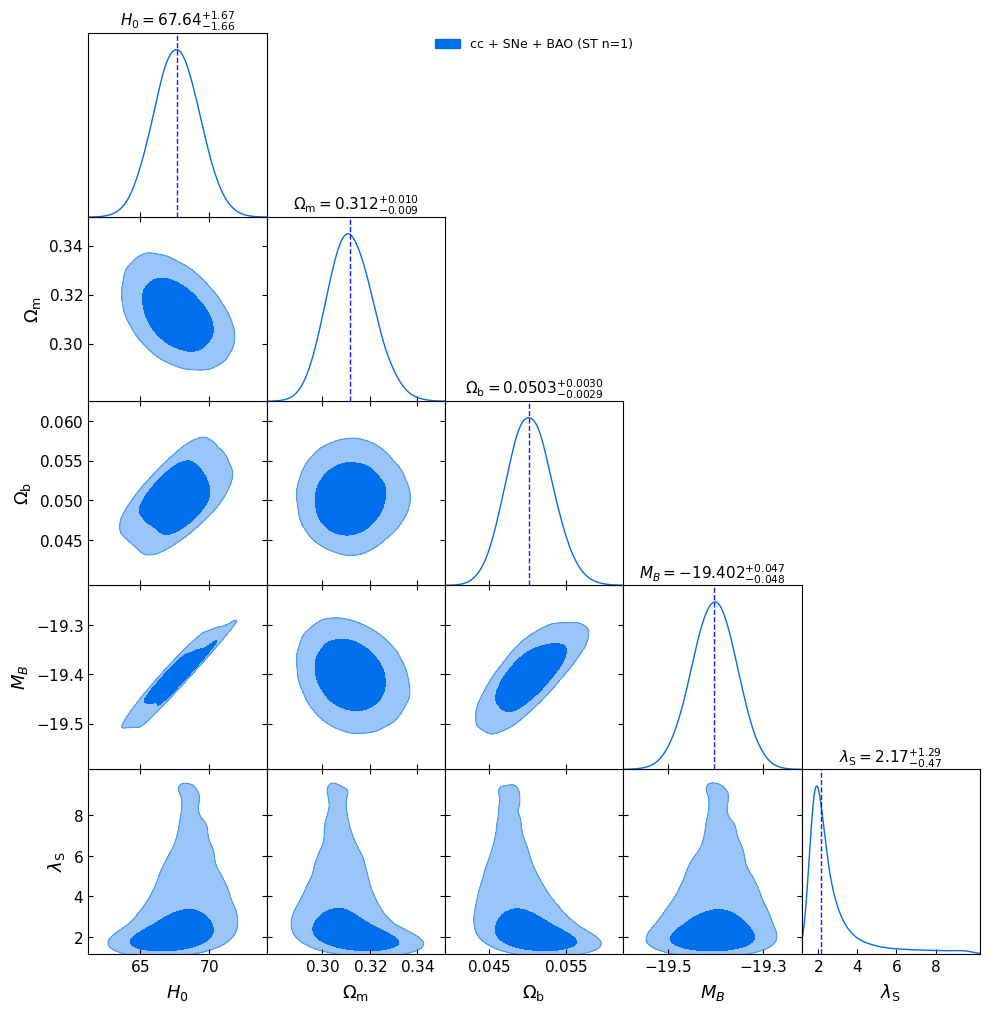

In [11]:
# ====================================================
# Corner plot (GetDist)
# ====================================================

param_names  = ["H0", "Om0", "Ob", "MB", "lbd"]
param_labels = [r"H_0", r"\Omega_{\rm m}", r"\Omega_{\rm b}", r"M_B", r"\lambda_{\rm S}"]
fmt_map      = {"H0": ".2f", "Om0": ".3f", "Ob": ".4f", "MB": ".3f", "lbd": ".2f"}

samples_gd = MCSamples(
    samples=flat_samples,          
    names=param_names,
    labels=param_labels
)

samples_gd.updateSettings({
    "smooth_scale_1D": 0.25,
    "smooth_scale_2D": 0.25,
    "fine_bins":       1024,
    "fine_bins_2D":    1024,
})

g = plots.get_subplot_plotter()
g.settings.axes_fontsize       = 14
g.settings.lab_fontsize        = 16
g.settings.legend_fontsize     = 12
g.settings.linewidth_contour   = 1.5
g.settings.num_plot_contours   = 2
g.settings.axis_marker_lw      = 1.0
g.settings.figure_legend_frame = False
g.settings.alpha_filled_add    = 0.3

g.triangle_plot(samples_gd, filled=True,
                legend_labels=[f"cc + SNe + BAO (ST n={n})"],
                title_limit=0)

# Add titles with median ± 68% CL
for i, name in enumerate(param_names):
    samp   = flat_samples[:, i]
    median  = np.percentile(samp, 50)
    lower68 = np.percentile(samp, 16)
    upper68 = np.percentile(samp, 84)
    ep68    = upper68 - median
    em68    = median  - lower68
    ax      = g.subplots[i, i]
    line    = ax.get_lines()[0]
    line.set_linewidth(1.0)
    ax.axvline(median, color="blue", lw=1.0, ls="--", alpha=0.9)
    fmt   = fmt_map[name]
    title = f"${param_labels[i]} = {median:{fmt}}^{{+{ep68:{fmt}}}}_{{-{em68:{fmt}}}}$"
    ax.set_title(title, fontsize=11, pad=4)

plt.subplots_adjust(top=0.95)
figname = f"Corner_ST_n{n}_cc_sne_bao.png"
plt.savefig(figname, dpi=300, bbox_inches="tight")
plt.show()

In [12]:
# ====================================================
# Marginalized statistics
# ====================================================

print("\n" + "="*60)
print(f"{'Final Inference Results (ST n='+str(n)+' | CC + SNe + BAO data)':^60}")
print("="*60)

for name, idx, fmt in [("H0",  0, ".2f"), 
                       ("Om0", 1, ".3f"), 
                       ("Ob",  2, ".4f"),
                       ("MB",  3, ".2f"),
                       ("lbd", 4, ".2f")]:
    samp    = flat_samples[:, idx]
    median  = np.percentile(samp, 50)
    lower68 = np.percentile(samp, 16)
    upper68 = np.percentile(samp, 84)
    lower95 = np.percentile(samp, 2.5)
    upper95 = np.percentile(samp, 97.5)
    ep68 = upper68 - median;  em68 = median - lower68
    ep95 = upper95 - median;  em95 = median - lower95
    print(f"\n  {name}:")
    print(f"    {median:{fmt}} +{ep68:{fmt}} -{em68:{fmt}}  (68% CL)")
    print(f"    {median:{fmt}} +{ep95:{fmt}} -{em95:.{fmt[1:]}}")

print("\n" + "="*60)


   Final Inference Results (ST n=1 | CC + SNe + BAO data)   

  H0:
    67.64 +1.67 -1.66  (68% CL)
    67.64 +3.28 -3.23

  Om0:
    0.312 +0.010 -0.009  (68% CL)
    0.312 +0.020 -0.018

  Ob:
    0.0503 +0.0030 -0.0029  (68% CL)
    0.0503 +0.0061 -0.0057

  MB:
    -19.40 +0.05 -0.05  (68% CL)
    -19.40 +0.09 -0.10

  lbd:
    2.17 +1.29 -0.47  (68% CL)
    2.17 +5.56 -0.61



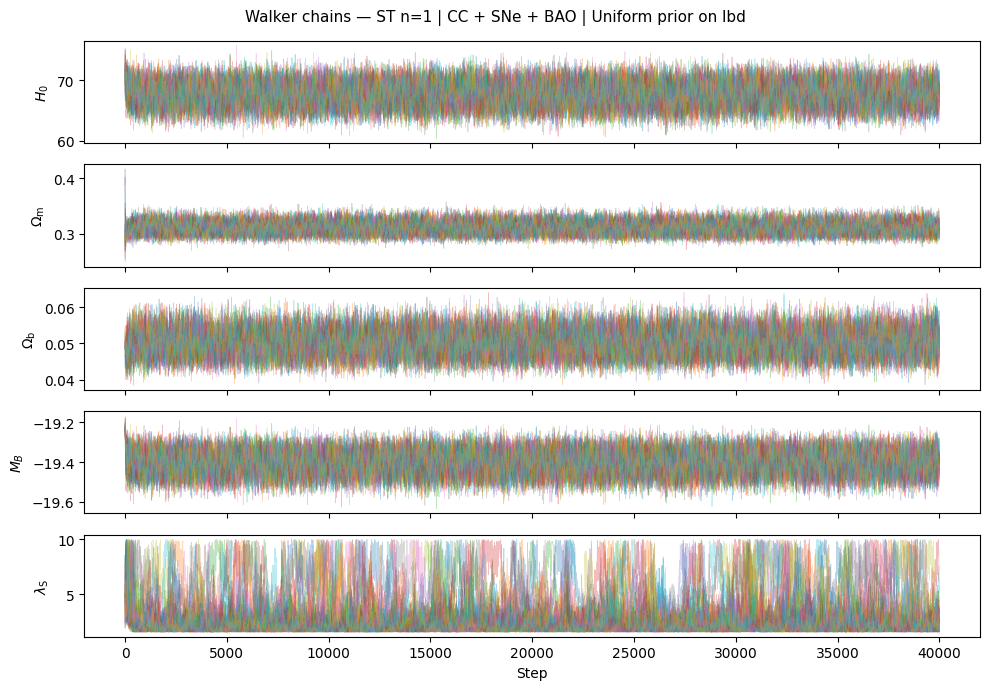

In [13]:
# ====================================================
# Walker chains
# ====================================================

chain_plot   = sampler.get_chain().copy()
chain_labels = [r"$H_0$", r"$\Omega_{\rm m}$", r"$\Omega_{\rm b}$",
                r"$M_B$", r"$\lambda_{\rm S}$"]

fig, axes = plt.subplots(5, figsize=(10, 7), sharex=True)

for i, label in enumerate(chain_labels):
    axes[i].plot(chain_plot[:, :, i], alpha=0.3, lw=0.5)
    axes[i].set_ylabel(label)
axes[-1].set_xlabel("Step")

plt.suptitle(f"Walker chains — ST n={n} | CC + SNe + BAO | Uniform prior on lbd",
             fontsize=11)

plt.tight_layout()
plt.show()

In [14]:
# ========================================================
# Derived Parameter: Sound Horizon rd
# ========================================================

def compute_rd(H0, Om0, Ob):
    h2   = (H0 / 100.0)**2
    Obh2 = Ob * h2
    Omh2 = Om0 * h2
    rd   = 147.05 * ((Obh2 / 0.02236)**-0.13) \
                  * ((Omh2 / 0.1432)**-0.23)  \
                  * ((Neff  / 3.04)**-0.1)
    return rd

# Compute rd for entire posterior
# flat_samples columns: [H0, Om0, Ob, MB, lbd]
rd_chain = np.array([
    compute_rd(s[0], s[1], s[2]) for s in flat_samples
])
mean_rd  = np.mean(rd_chain)
std_rd   = np.std(rd_chain)
lower_95 = np.percentile(rd_chain, 2.5)
upper_95 = np.percentile(rd_chain, 97.5)

print("\n" + "="*60)
print(f"{'Derived Sound Horizon':^60}")
print("="*60)
print(f"  r_d = {mean_rd:.3f} ± {std_rd:.3f} Mpc (68% CL)")
print(f"  95% CL : [{lower_95:.3f}, {upper_95:.3f}] Mpc")
print("="*60)


                   Derived Sound Horizon                    
  r_d = 146.676 ± 3.191 Mpc (68% CL)
  95% CL : [140.609, 153.127] Mpc
